# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Muhammad Alif Anshar
- **Email:** alif040105@gmail.com
- **ID Dicoding:** CDCC208D6Y2146

## Menentukan Pertanyaan Bisnis

Pertanyaan bisnis dirumuskan menggunakan kerangka **SMART** *(Specific, Measurable, Action-Oriented, Relevant, Time-bound)*.

**Pertanyaan 1:**
> *Kategori produk apa yang menghasilkan total pendapatan (revenue) tertinggi, dan bagaimana tren penjualannya secara bulanan sepanjang periode 2017 hingga 2018?*

- **Specific**: Fokus pada kategori produk dan tren penjualan bulanan.
- **Measurable**: Diukur menggunakan total payment_value per kategori produk.
- **Action-Oriented**: Membantu tim bisnis memprioritaskan kategori untuk dikembangkan.
- **Relevant**: Revenue adalah metrik utama keberhasilan e-commerce.
- **Time-bound**: Dibatasi pada periode 2017 hingga 2018 sebagai tahun data aktif.

**Pertanyaan 2:**
> *Bagaimana hubungan antara keterlambatan pengiriman (dalam hari) terhadap skor ulasan pelanggan, dan negara bagian mana yang memiliki rata-rata keterlambatan tertinggi selama periode 2017 hingga 2018?*

- **Specific**: Fokus pada keterlambatan pengiriman dan dampaknya terhadap review score.
- **Measurable**: Diukur dengan selisih hari antara estimated vs actual delivery dan rata-rata review score.
- **Action-Oriented**: Memberikan insight untuk perbaikan logistik di wilayah tertentu.
- **Relevant**: Keterlambatan memengaruhi kepuasan pelanggan dan reputasi platform.
- **Time-bound**: Dibatasi pada periode 2017 hingga 2018.


## Import Semua Packages/Library yang Digunakan

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "DejaVu Sans"
sns.set_theme(style="whitegrid", palette="muted")

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Data Wrangling

### Gathering Data

#### Load orders_dataset

In [47]:
orders_df = pd.read_csv(
    "data/orders_dataset.csv",
    parse_dates=["order_purchase_timestamp", "order_approved_at",
                 "order_delivered_carrier_date",
                 "order_delivered_customer_date",
                 "order_estimated_delivery_date"]
)
print(f"Shape: {orders_df.shape}")
orders_df.head()

Shape: (99441, 8)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


**Insight:**
- Dataset `order_dataset.csv` memiliki 99.441 baris dengan 8 kolom.
- Kolom timestamp diparsing menjadi tipe datetime untuk kemudahan analisis waktu.


#### Load order_items_dataset

In [48]:
order_items_df = pd.read_csv("data/order_items_dataset.csv")
print(f"Shape: {order_items_df.shape}")
order_items_df.head()

Shape: (112650, 7)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


**Insight:**
- Dataset `order_items_dataset.csv` memiliki 112.650 baris dengan 7 kolom.

#### Load order_payments_dataset

In [49]:
payments_df = pd.read_csv("data/order_payments_dataset.csv")
print(f"Shape: {payments_df.shape}")
payments_df.head()

Shape: (103886, 5)


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


**Insight:**
- Dataset `order_payments_dataset.csv` memiliki 103.886 baris dengan 5 kolom.

#### Load order_reviews_dataset

In [50]:
reviews_df = pd.read_csv(
    "data/order_reviews_dataset.csv",
    parse_dates=["review_creation_date", "review_answer_timestamp"]
)
print(f"Shape: {reviews_df.shape}")
reviews_df.head()

Shape: (99224, 7)


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53


**Insight:**
- Dataset `order_reviews_dataset.csv` memiliki 99.224 baris dengan 7 kolom.

#### Load products_dataset & translation

In [51]:
products_df = pd.read_csv("data/products_dataset.csv")
translation_df = pd.read_csv("data/product_category_name_translation.csv")
print(f"Products shape: {products_df.shape}")
print(f"Translation shape: {translation_df.shape}")
products_df.head()

Products shape: (32951, 9)
Translation shape: (71, 2)


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


**Insight:**
- Dataset `products_dataset.csv` memiliki 32951 baris dengan 9 kolom.
- Dataset `product_category_name_translation.csv` memiliki 71 baris dengan 2 kolom.

#### Load customers_dataset & sellers_dataset

In [52]:
customers_df = pd.read_csv("data/customers_dataset.csv")
sellers_df = pd.read_csv("data/sellers_dataset.csv")
print(f"Customers shape: {customers_df.shape}")
print(f"Sellers shape: {sellers_df.shape}")
customers_df.head()

Customers shape: (99441, 5)
Sellers shape: (3095, 4)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


**Insight:**
- Dataset `customers_dataset.csv` memiliki 99.441 baris dengan 5 kolom.
- Dataset `sellers_dataset.csv` memiliki 3095 baris dengan 4 kolom.

### Assessing Data

#### Identifying missing value problems

In [53]:
dfs = {
    "orders": orders_df, "order_items": order_items_df,
    "payments": payments_df, "reviews": reviews_df,
    "products": products_df, "customers": customers_df
}
for name, df in dfs.items():
    missing = df.isnull().sum()
    if missing.any():
        print(f"\n=== {name} ===")
        print(missing[missing > 0])


=== orders ===
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

=== reviews ===
review_comment_title      87656
review_comment_message    58247
dtype: int64

=== products ===
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


**Steps to Take (Missing Values):**
- `orders_df`: Kolom tanggal pengiriman memiliki missing values. Filter hanya pesanan berstatus "delivered" dan drop baris yang masih kosong.
- `reviews_df`: Kolom review komentar bersifat opsional dan wajar kosong. Tidak digunakan dalam analisis utama.
- `products_df`: Kolom atribut dimensi produk memiliki nilai kosong, namun kolom kategori yang digunakan akan di-drop saat join jika kosong.


#### Identifying duplicate data problems

In [54]:
for name, df in dfs.items():
    dups = df.duplicated().sum()
    print(f"{name}: {dups} duplicate rows")

orders: 0 duplicate rows
order_items: 0 duplicate rows
payments: 0 duplicate rows
reviews: 0 duplicate rows
products: 0 duplicate rows
customers: 0 duplicate rows


**Steps to Take (Duplicates):**
- Tidak ditemukan duplikat pada semua dataframe. Tidak diperlukan tindakan pembersihan untuk masalah ini.

#### Identifying invalid value problems

In [55]:
print("Order Status Distribution:")
print(orders_df["order_status"].value_counts())
print("\nPayment Type Distribution:")
print(payments_df["payment_type"].value_counts())

Order Status Distribution:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Payment Type Distribution:
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64


**Steps to Take (Invalid Values):**
- Terdapat 3 baris dengan payment_type bernilai "not_defined" yang merupakan nilai tidak valid dan akan difilter.
- Pesanan dengan status bukan "delivered" akan dikecualikan dari analisis pengiriman.


### Cleaning Data

#### Fixing missing values — filter delivered orders

In [56]:
orders_clean = orders_df[orders_df["order_status"] == "delivered"].copy()
orders_clean = orders_clean.dropna(subset=["order_delivered_customer_date",
                                            "order_estimated_delivery_date"])
orders_clean["delay_days"] = (
    orders_clean["order_delivered_customer_date"] -
    orders_clean["order_estimated_delivery_date"]
).dt.days
print(f"Orders clean shape: {orders_clean.shape}")
print(orders_clean["delay_days"].describe())

Orders clean shape: (96470, 9)
count    96470.000000
mean       -11.875889
std         10.182105
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delay_days, dtype: float64


**Insight:**
- Setelah filter, tersisa 96.470 pesanan delivered dengan data pengiriman lengkap.
- Rata-rata delay_days adalah -11.876, artinya rata-rata pengiriman 12 hari lebih cepat dari estimasi.
- Delay tertinggi mencapai 188, artinya pengiriman terlama dari estimasi mencapai 188.
- Delay terendah mencapai -147, artinya pengiriman 147 hari lebih cepat dari estimasi.

#### Fixing invalid payment type & aggregate payments

In [57]:
payments_clean = payments_df[payments_df["payment_type"] != "not_defined"].copy()
payment_agg = payments_clean.groupby("order_id")["payment_value"].sum().reset_index()
payment_agg.rename(columns={"payment_value": "total_payment"}, inplace=True)
print(f"Payment agg shape: {payment_agg.shape}")
payment_agg.head()

Payment agg shape: (99437, 2)


,order_id,total_payment
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04


#### Merge products with English category names

In [58]:
products_clean = products_df.merge(translation_df, on="product_category_name", how="left")
products_clean["product_category_name_english"].fillna(
    products_clean["product_category_name"], inplace=True
)
print(f"Products clean shape: {products_clean.shape}")
products_clean[["product_id", "product_category_name", "product_category_name_english"]].head()

Products clean shape: (32951, 10)


,product_id,product_category_name,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares


## Exploratory Data Analysis (EDA)

### Explore Revenue per Category

In [59]:
df_main = (
    orders_clean
    .merge(order_items_df[["order_id", "product_id"]], on="order_id")
    .merge(products_clean[["product_id", "product_category_name_english"]], on="product_id")
    .merge(payment_agg, on="order_id")
    .merge(customers_df[["customer_id", "customer_state"]], on="customer_id")
)
df_main = df_main[df_main["order_purchase_timestamp"].dt.year.isin([2017, 2018])].copy()
df_main["year_month"] = df_main["order_purchase_timestamp"].dt.to_period("M")
print(f"Master df shape: {df_main.shape}")

top_categories = (
    df_main.groupby("product_category_name_english")["total_payment"]
    .sum().sort_values(ascending=False).head(10).reset_index()
)
top_categories.columns = ["category", "total_revenue"]
print(top_categories)

Master df shape: (109872, 14)
                category  total_revenue
0         bed_bath_table     1690422.57
1          health_beauty     1615989.35
2  computers_accessories     1548390.63
3          watches_gifts     1384252.60
4        furniture_decor     1383767.32
5         sports_leisure     1346762.17
6             housewares     1067051.45
7                   auto      832259.57
8           garden_tools      809149.74
9             cool_stuff      743404.14


**Insight:**
- Kategori `bed_bath_table` menduduki posisi teratas, diikuti `health_beauty` dan `computers_accessories`.
- 10 kategori teratas mewakili porsi signifikan dari total pendapatan platform.


### Explore Monthly Revenue Trend (Top 3 Categories)

In [60]:
top3 = top_categories["category"].head(3).tolist()

monthly_top3 = (
    df_main[df_main["product_category_name_english"].isin(top3)]
    .groupby(["year_month", "product_category_name_english"])["total_payment"]
    .sum().reset_index()
)
monthly_top3["year_month"] = monthly_top3["year_month"].astype(str)
print(monthly_top3.head(60))

   year_month product_category_name_english  total_payment
0     2017-01                bed_bath_table        5875.24
1     2017-01         computers_accessories        6441.32
2     2017-01                 health_beauty       14248.86
3     2017-02                bed_bath_table       25022.10
4     2017-02         computers_accessories       14573.61
5     2017-02                 health_beauty       27708.90
6     2017-03                bed_bath_table       40874.27
7     2017-03         computers_accessories       39317.07
8     2017-03                 health_beauty       32140.54
9     2017-04                bed_bath_table       36487.57
10    2017-04         computers_accessories       24474.99
11    2017-04                 health_beauty       27564.76
12    2017-05                bed_bath_table       45529.30
13    2017-05         computers_accessories       81820.48
14    2017-05                 health_beauty       59197.21
15    2017-06                bed_bath_table       48639.

**Insight:**
- Tren menunjukkan pertumbuhan konsisten dari 2017 ke 2018.
- Lonjakan signifikan terjadi di Q4 2017 (November-Desember), mengindikasikan efek musiman akhir tahun.


### Explore Delivery Delay vs Review Score

In [61]:
delay_review = orders_clean.merge(
    reviews_df[["order_id", "review_score"]], on="order_id", how="left"
).merge(
    customers_df[["customer_id", "customer_state"]], on="customer_id"
)
delay_review = delay_review[
    delay_review["order_purchase_timestamp"].dt.year.isin([2017, 2018])
].dropna(subset=["review_score"])

delay_review["delay_category"] = pd.cut(
    delay_review["delay_days"],
    bins=[-np.inf, -14, -7, 0, 7, np.inf],
    labels=["Sangat Cepat (>14h)", "Cepat (7-14h)",
            "Tepat Waktu (0-7h)", "Terlambat (1-7h)", "Sangat Terlambat (>7h)"]
)
delay_avg = delay_review.groupby("delay_category")["review_score"].mean().reset_index()
print("Rata-rata review score per delay category:")
print(delay_avg)

state_delay = (
    delay_review.groupby("customer_state")
    .agg(avg_delay=("delay_days","mean"),
         avg_review=("review_score","mean"),
         count=("order_id","count"))
    .reset_index().sort_values("avg_delay", ascending=False)
)
print("\nTop 10 States dengan delay tertinggi:")
print(state_delay.head(27))

Rata-rata review score per delay category:
           delay_category  review_score
0     Sangat Cepat (>14h)      4.325042
1           Cepat (7-14h)      4.299563
2      Tepat Waktu (0-7h)      4.164548
3        Terlambat (1-7h)      2.713099
4  Sangat Terlambat (>7h)      1.700179

Top 10 States dengan delay tertinggi:
   customer_state  avg_delay  avg_review  count
1              AL  -8.758186    3.841310    397
9              MA  -9.551192    3.835905    713
24             SE  -9.903323    3.900302    331
7              ES -10.641519    4.082532   1975
5              CE -10.693701    3.933858   1270
4              BA -10.857231    3.929078   3243
11             MS -11.016901    4.169014    710
25             SP -11.047942    4.246917  40382
16             PI -11.225053    3.995754    471
23             SC -11.489501    4.131669   3524
18             RJ -11.735256    3.963486  12242
6              DF -11.943351    4.134422   2083
26             TO -12.106227    4.153846    273
8     

**Insight:**
- Terdapat korelasi negatif yang jelas: Semakin kecil selisih waktu pengiriman terhadap estimasi (semakin mepet), semakin rendah skor review-nya.
- State AL dan MA memiliki rata-rata delay tertinggi, kemungkinan karena infrastruktur logistik yang terbatas.
- State AC dan RO memiliki rata-rata delay terendah hingga mencapai -20 (20 hari lebih cepat)

## Visualization & Explanatory Analysis

### Pertanyaan 1: Top 10 Kategori Revenue & Tren Bulanan (2017-2018)

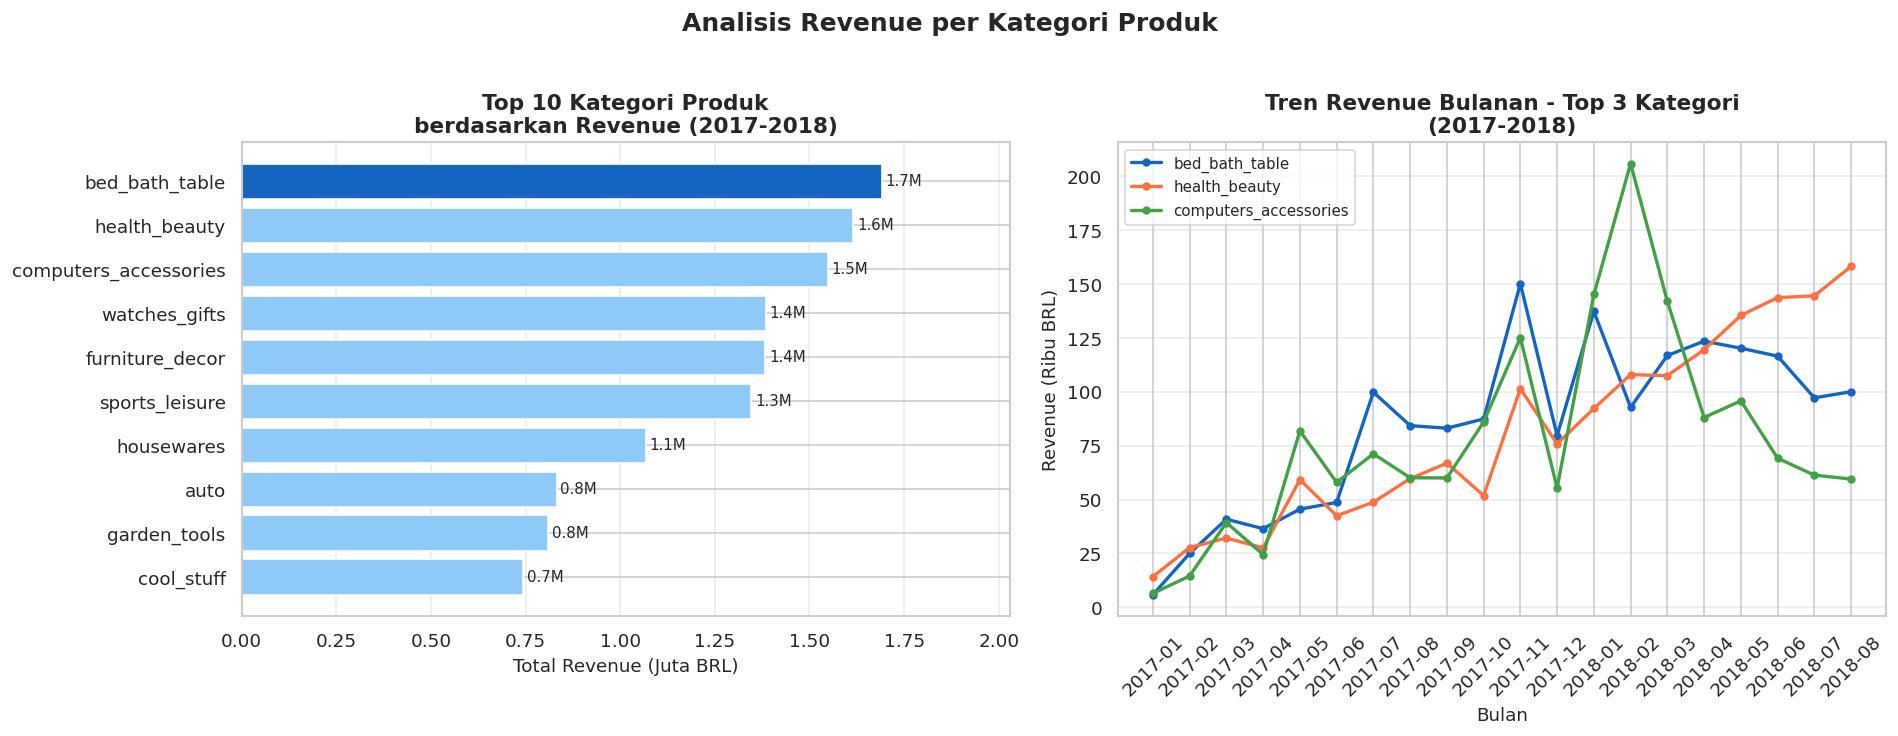

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart top 10 kategori
colors = ["#1565C0" if i == 0 else "#90CAF9" for i in range(len(top_categories))]
axes[0].barh(
    top_categories["category"][::-1],
    top_categories["total_revenue"][::-1] / 1e6,
    color=colors[::-1], edgecolor="white"
)
axes[0].set_xlabel("Total Revenue (Juta BRL)", fontsize=11)
axes[0].set_title("Top 10 Kategori Produk\nberdasarkan Revenue (2017-2018)",
                   fontsize=13, fontweight="bold")
for i, (val, cat) in enumerate(zip(top_categories["total_revenue"][::-1]/1e6,
                                    top_categories["category"][::-1])):
    axes[0].text(val + 0.01, i, f"{val:.1f}M", va="center", fontsize=9)
axes[0].set_xlim(0, top_categories["total_revenue"].max()/1e6 * 1.2)
axes[0].grid(axis="x", alpha=0.4)

# Line chart tren top 3
palette = {
    top3[0]: "#1565C0",
    top3[1]: "#FF7043",
    top3[2]: "#43A047"
}
for cat in top3:
    sub = monthly_top3[monthly_top3["product_category_name_english"] == cat]
    axes[1].plot(sub["year_month"], sub["total_payment"]/1e3,
                 marker="o", markersize=4, linewidth=2,
                 label=cat, color=palette[cat])
axes[1].set_xlabel("Bulan", fontsize=11)
axes[1].set_ylabel("Revenue (Ribu BRL)", fontsize=11)
axes[1].set_title("Tren Revenue Bulanan - Top 3 Kategori\n(2017-2018)",
                   fontsize=13, fontweight="bold")
axes[1].legend(fontsize=9, loc="upper left")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y", alpha=0.4)

plt.suptitle("Analisis Revenue per Kategori Produk", fontsize=15,
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("plot_q1.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight:**
- Produk bed_bath_table memiliki revenue paling atas dari tahun 2017-2018, diikuti dengan health_beauty dan computers_accessories.
- computers_accessories pada tren revenue bulanan memiliki lonjakan yang signifikan pada bulan 2018-02, sekaligus menjadi titik paling tinggi pada chart tersebut.

### Pertanyaan 2: Keterlambatan Pengiriman & Review Score per State (2017-2018)

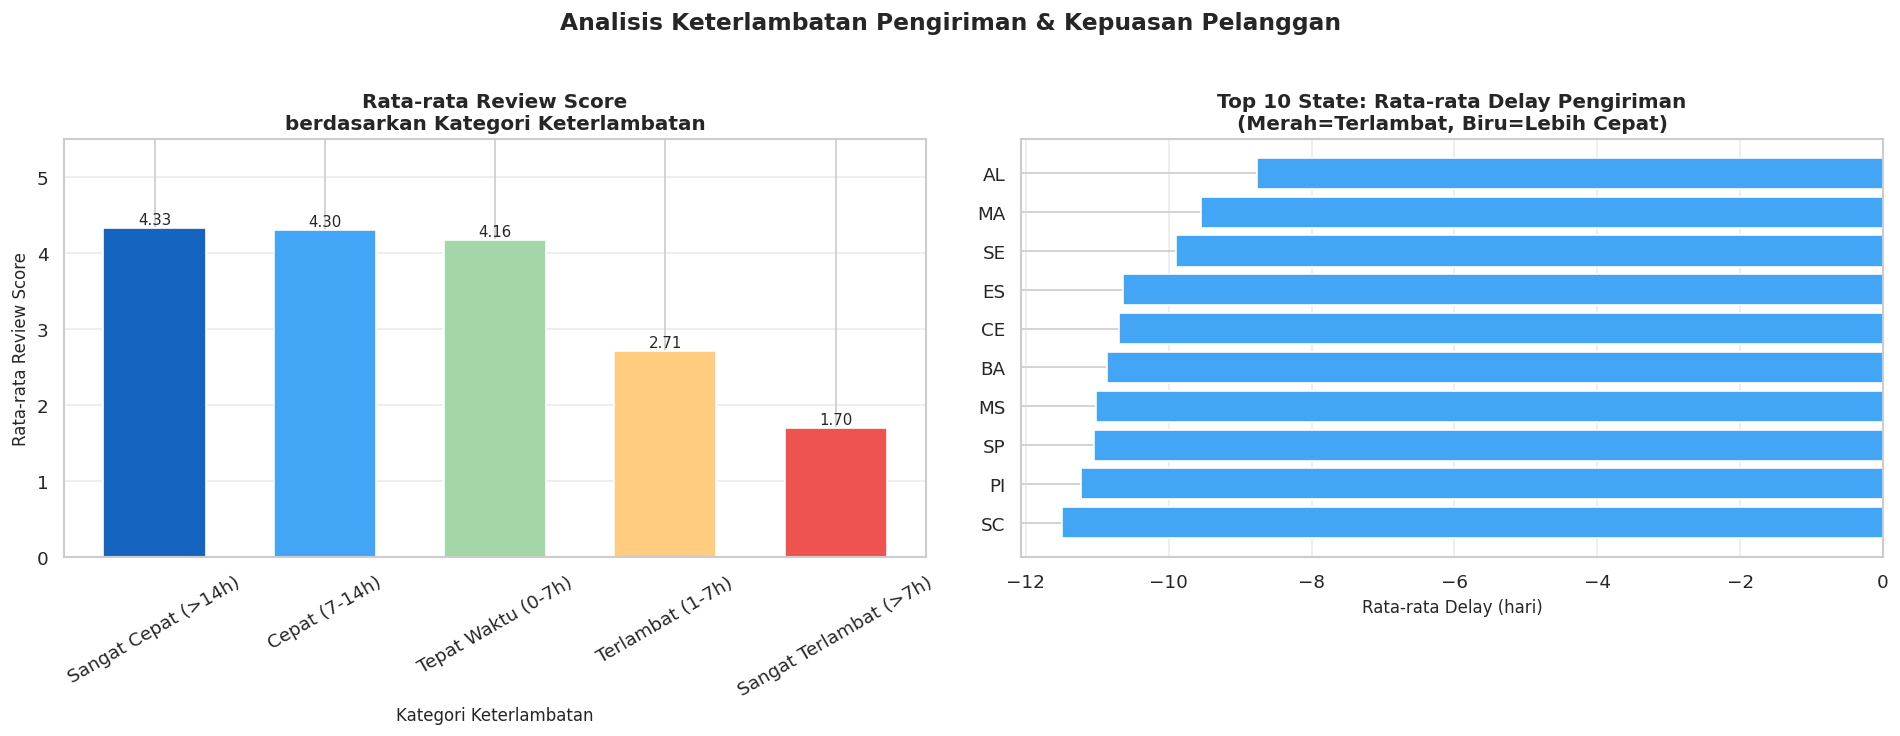

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart review score per delay category
delay_colors = ["#1565C0", "#42A5F5", "#A5D6A7", "#FFCC80", "#EF5350"]
bars = axes[0].bar(
    delay_avg["delay_category"].astype(str),
    delay_avg["review_score"],
    color=delay_colors, edgecolor="white", width=0.6
)
axes[0].set_ylim(0, 5.5)
axes[0].set_xlabel("Kategori Keterlambatan", fontsize=10)
axes[0].set_ylabel("Rata-rata Review Score", fontsize=10)
axes[0].set_title("Rata-rata Review Score\nberdasarkan Kategori Keterlambatan",
                   fontsize=12, fontweight="bold")
axes[0].tick_params(axis="x", rotation=30)
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.05,
                 f"{h:.2f}", ha="center", fontsize=9)
axes[0].grid(axis="y", alpha=0.4)

# Horizontal bar: top 10 states by delay
top10_state = state_delay.head(10)
bar_c = ["#EF5350" if v > 0 else "#42A5F5" for v in top10_state["avg_delay"]]
axes[1].barh(
    top10_state["customer_state"][::-1],
    top10_state["avg_delay"][::-1],
    color=bar_c[::-1], edgecolor="white"
)
axes[1].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_xlabel("Rata-rata Delay (hari)", fontsize=10)
axes[1].set_title("Top 10 State: Rata-rata Delay Pengiriman\n(Merah=Terlambat, Biru=Lebih Cepat)",
                   fontsize=12, fontweight="bold")
axes[1].grid(axis="x", alpha=0.4)

plt.suptitle("Analisis Keterlambatan Pengiriman & Kepuasan Pelanggan",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("plot_q2.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight:**
- Pada rata-rata review score dapat terlihat bahwa semakin terlambat rata rata review score makin menurun.
- Dari top 10 state (rata-rata delay pengiriman) tidak ada bar merah, yang menandakan bahwa rata-rata pengiriman tidak ada yang terlambar.
- Rata-rata delay pengiriman tertinggi dialami oleh state AL.

## Analisis Lanjutan: RFM Analysis

RFM Analysis bertujuan **mengelompokkan pelanggan berdasarkan perilaku pembelian** dengan tiga dimensi:
- **Recency (R)**: Berapa hari sejak terakhir melakukan pembelian (semakin kecil semakin baik).
- **Frequency (F)**: Jumlah transaksi unik yang dilakukan pelanggan.
- **Monetary (M)**: Total nilai pembayaran pelanggan.

Setiap dimensi di-bin ke dalam skor 1-5 (5 = terbaik), lalu pelanggan dikelompokkan ke dalam segmen bisnis.


In [64]:
snapshot_date = orders_clean["order_purchase_timestamp"].max() + pd.Timedelta(days=1)
print(f"Snapshot date: {snapshot_date.date()}")

rfm_base = (
    orders_clean
    .merge(payment_agg, on="order_id")
    .merge(customers_df[["customer_id", "customer_unique_id"]], on="customer_id")
)

rfm = rfm_base.groupby("customer_unique_id").agg(
    Recency=("order_purchase_timestamp", lambda x: (snapshot_date - x.max()).days),
    Frequency=("order_id", "nunique"),
    Monetary=("total_payment", "sum")
).reset_index()

rfm["R_Score"] = pd.qcut(rfm["Recency"], q=5, labels=[5,4,3,2,1]).astype(int)
rfm["F_Score"] = pd.cut(rfm["Frequency"], bins=[0,1,2,3,5,np.inf],
                         labels=[1,2,3,4,5]).astype(int)
rfm["M_Score"] = pd.qcut(rfm["Monetary"], q=5, labels=[1,2,3,4,5]).astype(int)
rfm["RFM_Score"] = rfm["R_Score"].astype(str) + rfm["F_Score"].astype(str) + rfm["M_Score"].astype(str)
rfm["RFM_Total"] = rfm["R_Score"] + rfm["F_Score"] + rfm["M_Score"]

def segment(row):
    r, f, m = row["R_Score"], row["F_Score"], row["M_Score"]
    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    elif r >= 4 and f >= 2:
        return "Loyal Customers"
    elif r >= 3 and f <= 2 and m >= 3:
        return "Potential Loyalists"
    elif r >= 4 and f == 1 and m <= 2:
        return "New Customers"
    elif r <= 2 and f >= 3:
        return "At Risk"
    elif r == 1 and f == 1:
        return "Lost"
    else:
        return "Others"

rfm["Segment"] = rfm.apply(segment, axis=1)
print(rfm["Segment"].value_counts())
rfm.head()

Snapshot date: 2018-08-30
Segment
Potential Loyalists    32989
Others                 26536
Lost                   18202
New Customers          14344
Loyal Customers         1176
At Risk                   69
Champions                 33
Name: count, dtype: int64


,customer_unique_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total,Segment
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4,414,9,Potential Loyalists
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1,411,6,New Customers
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,112,4,Lost
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,211,4,Others
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4,214,7,Others


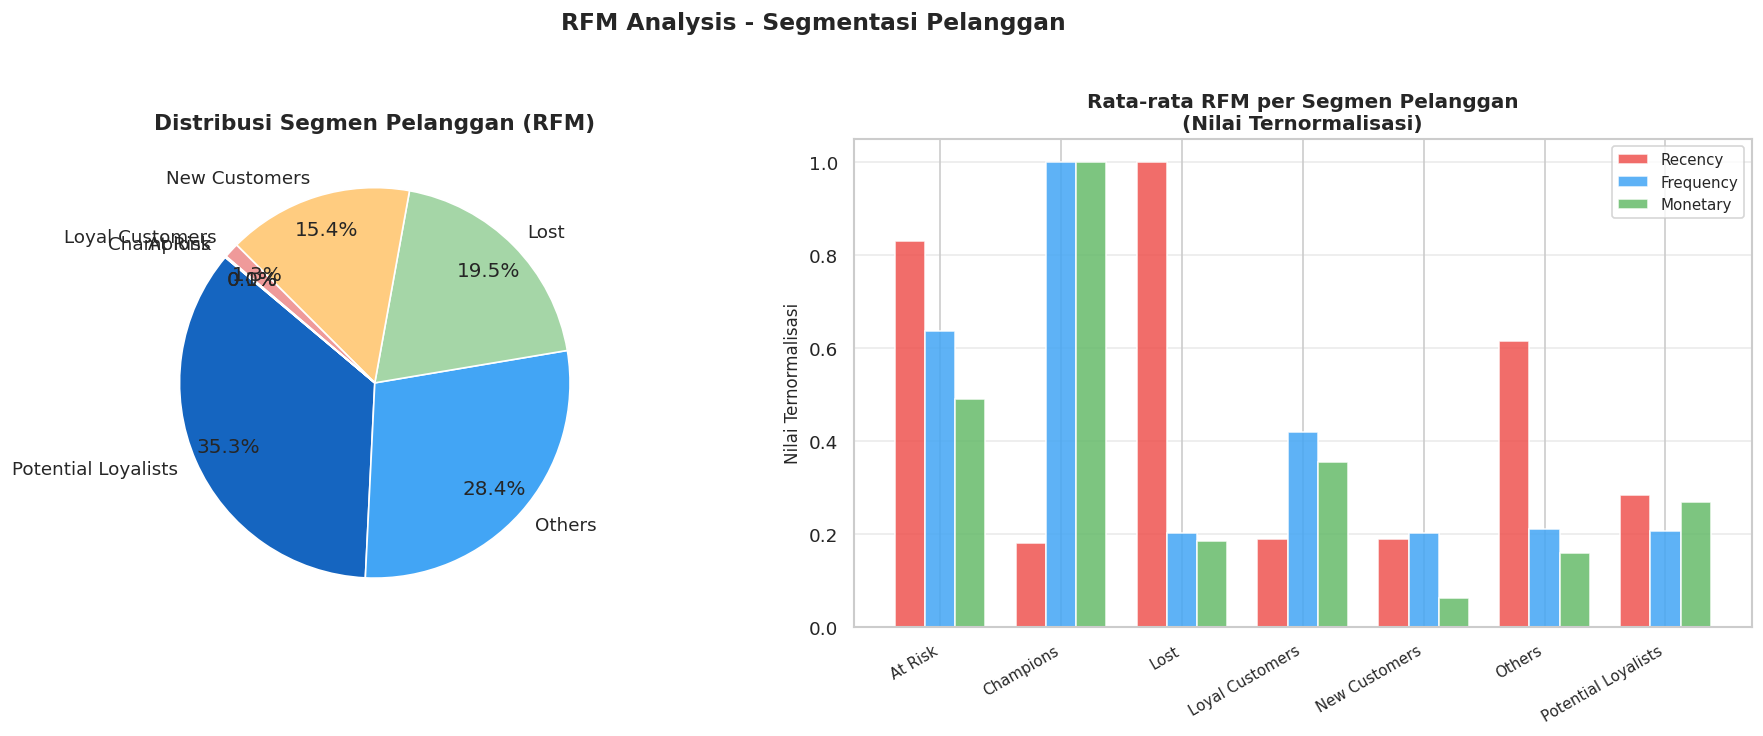

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart segmen
seg_counts = rfm["Segment"].value_counts()
seg_colors = ["#1565C0","#42A5F5","#A5D6A7","#FFCC80","#EF9A9A","#B0BEC5","#CE93D8"]
axes[0].pie(
    seg_counts, labels=seg_counts.index,
    autopct="%1.1f%%", colors=seg_colors[:len(seg_counts)],
    startangle=140, pctdistance=0.82
)
axes[0].set_title("Distribusi Segmen Pelanggan (RFM)",
                   fontsize=13, fontweight="bold")

# Bar chart rata-rata nilai per segmen
rfm_seg = rfm.groupby("Segment")[["Recency","Frequency","Monetary"]].mean().reset_index()
x = np.arange(len(rfm_seg))
width = 0.25
# Normalize
r_norm = rfm_seg["Recency"] / rfm_seg["Recency"].max()
f_norm = rfm_seg["Frequency"] / rfm_seg["Frequency"].max()
m_norm = rfm_seg["Monetary"] / rfm_seg["Monetary"].max()

axes[1].bar(x - width, r_norm, width, label="Recency", color="#EF5350", alpha=0.85)
axes[1].bar(x, f_norm, width, label="Frequency", color="#42A5F5", alpha=0.85)
axes[1].bar(x + width, m_norm, width, label="Monetary", color="#66BB6A", alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(rfm_seg["Segment"], rotation=30, ha="right", fontsize=9)
axes[1].set_ylabel("Nilai Ternormalisasi", fontsize=10)
axes[1].set_title("Rata-rata RFM per Segmen Pelanggan\n(Nilai Ternormalisasi)",
                   fontsize=12, fontweight="bold")
axes[1].legend(fontsize=9)
axes[1].grid(axis="y", alpha=0.4)

plt.suptitle("RFM Analysis - Segmentasi Pelanggan",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("plot_rfm.png", dpi=150, bbox_inches="tight")
plt.show()

### Menyimpan Data untuk Dashboard

In [66]:
os.makedirs("dashboard", exist_ok=True)

main_data = df_main.copy()
main_data["year_month"] = main_data["year_month"].astype(str)

delay_info = delay_review[["order_id","delay_days","review_score","delay_category"]].drop_duplicates("order_id")
main_data = main_data.merge(delay_info, on="order_id", how="left")
main_data = main_data.drop(columns=["delay_days_x"])
main_data = main_data.rename(columns={"delay_days_y": "delay_days"})

rfm.to_csv("dashboard/rfm_data.csv", index=False)
main_data.to_csv("dashboard/main_data.csv", index=False)
print(f"main_data saved: {main_data.shape}")
print(f"rfm_data saved: {rfm.shape}")

main_data saved: (109872, 16)
rfm_data saved: (93349, 10)


## Conclusion & Recommendation

### Kesimpulan

**Conclusion Pertanyaan 1 - Revenue per Kategori (2017-2018):**
Kategori `bed_bath_table` (\~1,69 juta BRL), `health_beauty` (\~1,62 juta BRL), dan `computers_accessories` (\~1,55 juta BRL) adalah tiga kontributor revenue terbesar. Tren bulanan menunjukkan pertumbuhan konsisten sepanjang 2017, dengan lonjakan di Q4 2017 (November-Desember) yang mengindikasikan efek musiman akhir tahun. Pada 2018, pertumbuhan lebih stabil namun tetap positif.

**Conclusion Pertanyaan 2 - Keterlambatan & Review Score (2017-2018):**
Terdapat hubungan negatif yang jelas antara keterlambatan pengiriman dan review score. Pelanggan yang menerima pesanan lebih dari 14 hari lebih cepat dari estimasi memberikan rata-rata skor 4.3, sementara yang mengalami keterlambatan lebih dari 7 hari hanya memberikan skor rata-rata 1.7. State AL dan MA mencatat delay tertinggi, kemungkinan karena infrastruktur logistik terbatas.

**Conclusion Analisis Lanjutan - RFM Segmentation:**
Analisis RFM menunjukkan bahwa meskipun database didominasi oleh pembeli satu kali transaksi (segmen Others & Potential Loyalists), terdapat aset besar berupa 32.989 pelanggan potensial yang baru saja bertransaksi dengan nilai tinggi. Prioritas utama adalah mengonversi 'Potential Loyalists' menjadi 'Loyal Customers' melalui program retensi, serta melakukan intervensi cepat pada segmen 'At Risk' sebelum mereka jatuh ke kategori 'Lost'.


### Rekomendasi Action Item

1. **Fokus Promosi pada Kategori Unggulan**: Tingkatkan anggaran iklan untuk kategori `bed_bath_table` dan `health_beauty` terutama menjelang Q4 untuk memaksimalkan efek musiman.
2. **Perbaiki Logistik di State Terpencil**: Jalin kemitraan dengan kurir lokal atau bangun hub distribusi di wilayah RR, AP, dan AM untuk mempercepat pengiriman.
3. **Program Retensi Berbasis RFM**: Buat kampanye berbeda - reward eksklusif untuk "Champions", diskon win-back untuk "At Risk", dan onboarding gifts untuk "New Customers".
4. **Optimasi Estimasi Pengiriman**: Tampilkan estimasi yang lebih akurat di halaman produk. Pelanggan yang menerima paket lebih cepat dari estimasi memberikan ulasan jauh lebih positif.
